In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
g=9.81
Ts=0.005

In [2]:
class X():
    def __init__(self,state=np.zeros(6)):
        self.x,self.y,self.phi=state[0],state[1],state[2]
        self.xDot,self.yDot,self.phiDot=state[3],state[4],state[5]
    def __call__(self):
        return [self.x,self.y,self.phi,self.xDot,self.yDot,self.phiDot]




In [3]:
class Obstacle:
    def __init__(self,x,y,r):
        self.c=np.array([x,y])
        self.r=r
    def CheckCollisionThroughTime(self,state):
        nChecks=state.shape[1]
        for i in range(nChecks):
            currentState=X(state[:,i])
            if self.CheckCollision([currentState.x,currentState.y]):
                return 1
        return 0
    def CheckCollision(self,point,offset=0):
        distance=np.linalg.norm(np.array(point-self.c))
        if distance<=(self.r+offset):
            return 1
    def __call__(self):
        return self.c,self.r
    


In [4]:
from scipy.integrate import solve_ivp
goalWidth=20
XLim=800
floor=0
cieling=450

class Quadcopter:
    def __init__(self, m=0.18, L=0.086, J=1.5e-4):
        self.m, self.L, self.J = m, L, J
        self.g = 9.81
        self.state = X()

    def step(self, action, dt):
        u = np.clip(action, -1.0, 1.0)
        F = ((u[0] + 1)/2) * (1.8 * self.m * self.g)
        M = u[1] * 0.02

        s = np.array([self.state.x, self.state.y, self.state.phi, 
                      self.state.xDot, self.state.yDot, self.state.phiDot])
        
        # Dynamics
        def f(st, f_val, m_val):
            return np.array([
                st[3], st[4], st[5],
                -(f_val/self.m)*np.sin(st[2]),
                (f_val/self.m)*np.cos(st[2]) - self.g,
                m_val/self.J
            ])

        k1 = f(s, F, M)
        k2 = f(s + 0.5*dt*k1, F, M)
        k3 = f(s + 0.5*dt*k2, F, M)
        k4 = f(s + dt*k3, F, M)
        
        self.state = X(s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4))

In [5]:
class TimeOptimalNavEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.quad = Quadcopter()
        self.dt = 0.02
        self.max_steps = 800

        self.bounds = np.array([0, 800, 0, 450])
        self.goal_radius = 25.0

        self.alpha = 5.0        # shaping strength
        self.R_goal = 500.0
        self.R_crash = 300.0

        self.n_lidar = 8

        self.action_space = spaces.Box(-1, 1, (2,), np.float32)
        self.observation_space = spaces.Box(-1, 1, (7 + self.n_lidar,), np.float32)
    def _get_obs(self):
        s = self.quad.state

        rel = (self.goal - np.array([s.x, s.y])) / 800.0
        vel = np.array([s.xDot, s.yDot]) / 10.0

        ang = np.array([np.sin(s.phi), np.cos(s.phi)])
        ang_vel = np.array([s.phiDot / 5.0])

        lidar = self._get_lidar()

        return np.concatenate([rel, vel, ang, ang_vel, lidar]).astype(np.float32)
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0

        # random start and goal
        self.start = np.random.uniform([50, 50], [750, 400])
        self.goal = np.random.uniform([50, 50], [750, 400])

        self.quad.state = X(np.array([self.start[0], self.start[1], 0, 0, 0, 0]))
        self.prev_dist = np.linalg.norm(self.goal - self.start)

        return self._get_obs(), {}
    def _get_lidar(self):
        return np.ones(self.n_lidar, dtype=np.float32)
    def step(self, action):
        self.steps += 1
        self.quad.step(action, self.dt)

        s = self.quad.state
        pos = np.array([s.x, s.y])
        dist = np.linalg.norm(self.goal - pos)

        # reward section
        reward = -1.0
        reward += self.alpha * (self.prev_dist - dist)
        self.prev_dist = dist

        terminated = False

        # goal
        if dist < self.goal_radius:
            reward += self.R_goal
            terminated = True

        # crash
        if not (0 <= s.x <= 800 and 0 <= s.y <= 450):
            reward -= self.R_crash
            terminated = True

        truncated = self.steps >= self.max_steps
        return self._get_obs(), reward, terminated, truncated, {}

In [6]:
from stable_baselines3 import SAC
from stable_baselines3.common.noise import NormalActionNoise

env = TimeOptimalNavEnv()


policy_kwargs = dict(
    net_arch=[256, 256]
)

model = SAC(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    buffer_size=1_000_000,
    learning_starts=10_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",          # critical for exploration
    policy_kwargs=policy_kwargs,
    verbose=1,
)

print("Training SAC time-optimal quadrotor...")
model.learn(total_timesteps=1000000)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training SAC time-optimal quadrotor...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 266      |
|    ep_rew_mean     | -844     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 3550     |
|    time_elapsed    | 0        |
|    total_timesteps | 1065     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 329      |
|    ep_rew_mean     | -777     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 3602     |
|    time_elapsed    | 0        |
|    total_timesteps | 2632     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 319      |
|    ep_rew_mean     | -788     |
| time/              |          |
|    episodes   

In [ ]:
model.save("")

In [ ]:
'''
env=TimeOptimalNavEnv()
env = TimeOptimalNavEnv()

model=PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.0,
    clip_range=0.2,
)
model.learn(total_timesteps=400000)
    
'''


KeyboardInterrupt: 

Time Taken: 12.20 seconds


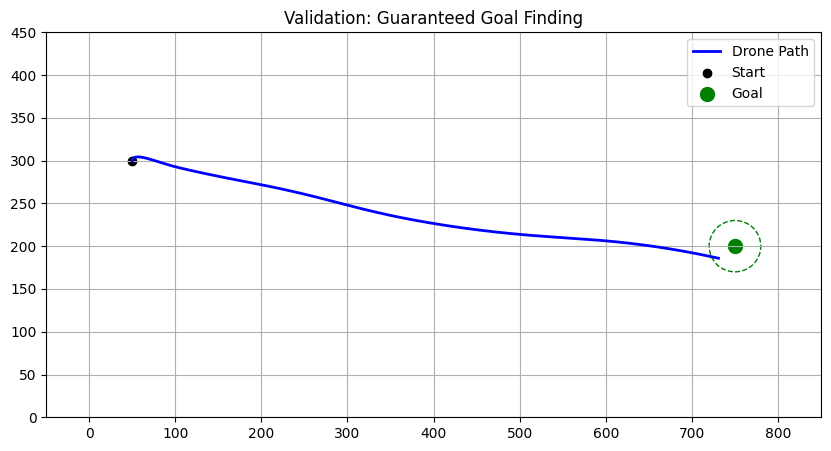

In [9]:
obs, _ = env.reset()

env.quad.state = X(np.array([50.0, 300.0, 0, 0, 0, 0]))
env.goal = np.array([750.0, 200.0])
env.prev_dist = np.linalg.norm(env.goal - np.array([50.0, 300.0]))

obs = env._get_obs()
path_x, path_y = [], []
done = False
steps = 0
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, _ = env.step(action)
    done = done or truncated
    path_x.append(env.quad.state.x)
    path_y.append(env.quad.state.y)
    steps+=1

time_taken = steps * env.dt 
print(f"Time Taken: {time_taken:.2f} seconds")
plt.figure(figsize=(10, 5))
plt.plot(path_x, path_y, 'b-', linewidth=2, label="Drone Path")
plt.scatter([50], [300], c='k', label="Start")
plt.scatter([750], [200], c='g', s=100, label="Goal")

# Draw Goal Zone
circle = plt.Circle((750, 200), 30, color='g', fill=False, linestyle='--')
plt.gca().add_patch(circle)

plt.title("Validation: Guaranteed Goal Finding")
plt.xlim(-50, 850)
plt.ylim(0, 450)
plt.grid(True)
plt.legend()
plt.show()